In [26]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal
import seaborn as sns


In [8]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41223 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:41223/status,
Dashboard: http://127.0.0.1:41223/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:34429,Workers: 0
Dashboard: http://127.0.0.1:41223/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39579,Total threads: 4
Dashboard: http://127.0.0.1:33059/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:38823,


2026-02-11 13:05:45,805 - distributed.nanny - WARNING - Restarting worker
2026-02-11 13:07:38,220 - distributed.nanny - WARNING - Restarting worker


In [3]:
path_atm = "/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds_19 = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

In [4]:
path_atm_22 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251125_pinatubo10Tg22_e01/atm/hist"
ds_22 = xr.open_mfdataset(f"{path_atm_22}/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [9]:
path_atm_19_c =  "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260116_pinatubo10tg_19_c/atm/hist"
ds_19_c = xr.open_mfdataset(f"{path_atm_19_c}/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fd04cc67240>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID
Exception ignored in: <function CachingFileManager.__del__ at 0x7fd04cc67240>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/ni

In [10]:
path_atm_24 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251129_pinatubo17Tg24_e01/atm/hist"
ds_24 = xr.open_mfdataset(f"{path_atm_24}/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fd04cc67240>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [11]:
path_atm_1825 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251204_pinatubo10Tg18_25_e01/atm/hist"
ds_1825 = xr.open_mfdataset(f"{path_atm_1825}/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7fd04cc67240>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [13]:
path_atm_1825_17tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251207_pinatubo17Tg18_25_e01/atm/hist"
ds_1825_17tg = xr.open_mfdataset(f"{path_atm_1825_17tg}/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7f1e5f886fc0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [14]:
path_atm_1tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251210_pinatubo1Tg19_e01/atm/hist"
ds_1tg = xr.open_mfdataset(f"{path_atm_1tg}/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7f1e5f886fc0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [15]:
path_atm_1pr = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251223_pinatubo10Tg_1pr/atm/hist"
ds_1pr = xr.open_mfdataset(f"{path_atm_1pr}/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7f1e5f886fc0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [16]:
path_atm_60tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260108_pinatubo60Tg19_e01/atm/hist"
ds_60tg = xr.open_mfdataset(f"{path_atm_60tg}/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7f1e5f886fc0>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [17]:
client.close()

In [18]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])
ds_1825 = ds_1825.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])
ds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])
ds_1tg = ds_1tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1pr['time'].values])
ds_1pr = ds_1pr.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_60tg['time'].values])
ds_60tg = ds_60tg.assign_coords(time=shifted_time)

In [19]:
lat = ds_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
lat_1825 = ds_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat_1825))
lat_1825_17tg = ds_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))
lat_1tg = ds_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))
lat_1pr = ds_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))
lat_60tg = ds_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))

In [20]:
netlwtom = ds_19["FLNT"].weighted(weighted_lat).mean(dim=["lat", "lon"])
baseline = netlwtom.sel(time=slice("1975-01", "1985-12"))
baseline = baseline.groupby("time.month").mean("time")
netlwtom_anom = netlwtom.groupby("time.month") - baseline
netlwtom_anom = netlwtom_anom.sel(time=slice("1991-01", "1996-01"))

In [21]:
netlwtom_19_c = ds_19_c["FLNT"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netlwtom_19_c_anom = netlwtom_19_c.groupby("time.month") - baseline

netlwtom_22 = ds_22["FLNT"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netlwtom_22_anom = netlwtom_22.groupby("time.month") - baseline

netlwtom_24 = ds_24["FLNT"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netlwtom_24_anom = netlwtom_24.groupby("time.month") - baseline

netlwtom_1825 = ds_1825["FLNT"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netlwtom_1825_anom = netlwtom_1825.groupby("time.month") - baseline

netlwtom_1825_17tg = ds_1825_17tg["FLNT"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netlwtom_1825_17tg_anom = netlwtom_1825_17tg.groupby("time.month") - baseline

netlwtom_1tg = ds_1tg["FLNT"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netlwtom_1tg_anom = netlwtom_1tg.groupby("time.month") - baseline

netlwtom_1pr = ds_1pr["FLNT"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netlwtom_1pr_anom = netlwtom_1pr.groupby("time.month") - baseline

netlwtom_60tg = ds_60tg["FLNT"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netlwtom_60tg_anom = netlwtom_60tg.groupby("time.month") - baseline

In [22]:
netswtom = ds_19["FSNT"].weighted(weighted_lat).mean(dim=["lat", "lon"])
baseline = netswtom.sel(time=slice("1975-01", "1985-12"))
baseline = baseline.groupby("time.month").mean("time")
netswtom_anom = netswtom.groupby("time.month") - baseline
netswtom_anom = netswtom_anom.sel(time=slice("1991-01", "1996-01"))

In [23]:
netswtom_19_c = ds_19_c["FSNT"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netswtom_19_c_anom = netswtom_19_c.groupby("time.month") - baseline

netswtom_22 = ds_22["FSNT"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netswtom_22_anom = netswtom_22.groupby("time.month") - baseline

netswtom_24 = ds_24["FSNT"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netswtom_24_anom = netswtom_24.groupby("time.month") - baseline

netswtom_1825 = ds_1825["FSNT"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netswtom_1825_anom = netswtom_1825.groupby("time.month") - baseline

netswtom_1825_17tg = ds_1825_17tg["FSNT"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netswtom_1825_17tg_anom = netswtom_1825_17tg.groupby("time.month") - baseline

netswtom_1tg = ds_1tg["FSNT"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netswtom_1tg_anom = netswtom_1tg.groupby("time.month") - baseline

netswtom_1pr = ds_1pr["FSNT"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netswtom_1pr_anom = netswtom_1pr.groupby("time.month") - baseline

netswtom_60tg = ds_60tg["FSNT"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netswtom_60tg_anom = netswtom_60tg.groupby("time.month") - baseline

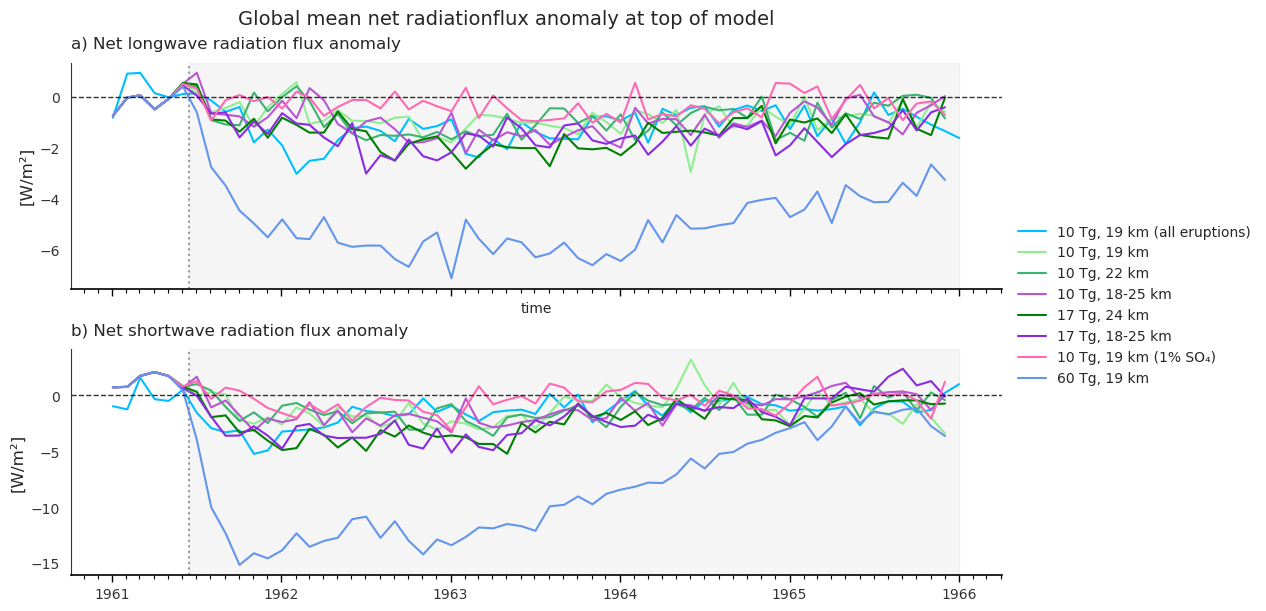

In [31]:
sns.set_style("whitegrid", {'axes.grid': False})
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'

eruption_date=cftime.DatetimeNoLeap(1991, 6, 15)

fig, (ax_lw, ax_sw) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, constrained_layout=True)

netlwtom_anom.plot(ax=ax_lw,color="deepskyblue",lw=1.5,label="10 Tg, 19 km (all eruptions)")
ax_lw.plot(netlwtom_19_c_anom.time, netlwtom_19_c_anom,color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax_lw.plot(netlwtom_22_anom.time, netlwtom_22_anom,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax_lw.plot(netlwtom_1825_anom.time, netlwtom_1825_anom,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax_lw.plot(netlwtom_24_anom.time, netlwtom_24_anom,color="green", lw=1.5,label="17 Tg, 24 km")
ax_lw.plot(netlwtom_1825_17tg_anom.time, netlwtom_1825_17tg_anom,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax_lw.plot(netlwtom_1pr_anom.time, netlwtom_1pr_anom,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax_lw.plot(netlwtom_60tg_anom.time, netlwtom_60tg_anom,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km")

ax_lw.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1, 7)))

ax_sw.plot(netswtom_anom.time, netswtom_anom,color="deepskyblue", lw=1.5)
ax_sw.plot(netswtom_19_c_anom.time, netswtom_19_c_anom,color="lightgreen", lw=1.5)
ax_sw.plot(netswtom_22_anom.time, netswtom_22_anom,color="mediumseagreen", lw=1.5)
ax_sw.plot(netswtom_1825_anom.time, netswtom_1825_anom,color="mediumorchid", lw=1.5)
ax_sw.plot(netswtom_24_anom.time, netswtom_24_anom,color="green", lw=1.5)
ax_sw.plot(netswtom_1825_17tg_anom.time, netswtom_1825_17tg_anom,color="blueviolet", lw=1.5)
ax_sw.plot(netswtom_1pr_anom.time, netswtom_1pr_anom,color="hotpink", lw=1.5)
ax_sw.plot(netswtom_60tg_anom.time, netswtom_60tg_anom,color="cornflowerblue", lw=1.5)

ax_sw.xaxis.set_major_locator(mdates.YearLocator())
ax_sw.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax_sw.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1, 7)))

axes = [ax_lw, ax_sw]
titles = ["a) Net longwave radiation flux anomaly", "b) Net shortwave radiation flux anomaly"]

for i, ax in enumerate(axes):
    ax.axhline(0, color="black", lw=1.0, ls='--', alpha=0.8)
    ax.axvline(eruption_date, color='gray', ls = ":", alpha=0.8)
    ax.axvspan(eruption_date, cftime.DatetimeNoLeap(1996, 1, 1), color='gray', alpha=0.08, zorder=0)
    ax.tick_params(direction='out', length=4)
    ax.set_ylabel("[W/m²]", fontsize=12)
    ax.set_title(titles[i], loc='left', fontsize=12, pad=10)
    
    sns.despine(ax=ax)

for ax in [ax_lw, ax_sw]:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_minor_locator(mdates.MonthLocator()) 
    
    ax.tick_params(axis='x', which='major', bottom=True, length=5, width=1, color='black')
    ax.tick_params(axis='x', which='minor', bottom=True, length=3, width=0.8, color='black')
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.2)

ax_sw.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle("Global mean net radiationflux anomaly at top of model", fontsize=14)

fig.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=10
)


plt.show()


In [32]:
netlwsurf = ds_19["FLNS"].weighted(weighted_lat).mean(dim=["lat", "lon"])
baseline = netlwsurf.sel(time=slice("1975-01", "1985-12"))
baseline = baseline.groupby("time.month").mean("time")
netlwsurf_anom = netlwsurf.groupby("time.month") - baseline
netlwsurf_anom = netlwsurf_anom.sel(time=slice("1991-01", "1996-01"))

In [33]:
netlwsurf_19_c = ds_19_c["FLNS"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netlwsurf_19_c_anom = netlwsurf_19_c.groupby("time.month") - baseline

netlwsurf_22 = ds_22["FLNS"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netlwsurf_22_anom = netlwsurf_22.groupby("time.month") - baseline

netlwsurf_24 = ds_24["FLNS"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netlwsurf_24_anom = netlwsurf_24.groupby("time.month") - baseline

netlwsurf_1825 = ds_1825["FLNS"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netlwsurf_1825_anom = netlwsurf_1825.groupby("time.month") - baseline

netlwsurf_1825_17tg = ds_1825_17tg["FLNS"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netlwsurf_1825_17tg_anom = netlwsurf_1825_17tg.groupby("time.month") - baseline

netlwsurf_1tg = ds_1tg["FLNS"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netlwsurf_1tg_anom = netlwsurf_1tg.groupby("time.month") - baseline

netlwsurf_1pr = ds_1pr["FLNS"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netlwsurf_1pr_anom = netlwsurf_1pr.groupby("time.month") - baseline

netlwsurf_60tg = ds_60tg["FLNS"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netlwsurf_60tg_anom = netlwsurf_60tg.groupby("time.month") - baseline

In [34]:
netswsurf = ds_19["FSNS"].weighted(weighted_lat).mean(dim=["lat", "lon"])
baseline = netswsurf.sel(time=slice("1975-01", "1985-12"))
baseline = baseline.groupby("time.month").mean("time")
netswsurf_anom = netswsurf.groupby("time.month") - baseline
netswsurf_anom = netswsurf_anom.sel(time=slice("1991-01", "1996-01"))

In [35]:
netswsurf_19_c = ds_19_c["FSNS"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
netswsurf_19_c_anom = netswsurf_19_c.groupby("time.month") - baseline

netswsurf_22 = ds_22["FSNS"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
netswsurf_22_anom = netswsurf_22.groupby("time.month") - baseline

netswsurf_24 = ds_24["FSNS"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
netswsurf_24_anom = netswsurf_24.groupby("time.month") - baseline

netswsurf_1825 = ds_1825["FSNS"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
netswsurf_1825_anom = netswsurf_1825.groupby("time.month") - baseline

netswsurf_1825_17tg = ds_1825_17tg["FSNS"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
netswsurf_1825_17tg_anom = netswsurf_1825_17tg.groupby("time.month") - baseline

netswsurf_1tg = ds_1tg["FSNS"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
netswsurf_1tg_anom = netswsurf_1tg.groupby("time.month") - baseline

netswsurf_1pr = ds_1pr["FSNS"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
netswsurf_1pr_anom = netswsurf_1pr.groupby("time.month") - baseline

netswsurf_60tg = ds_60tg["FSNS"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
netswsurf_60tg_anom = netswsurf_60tg.groupby("time.month") - baseline

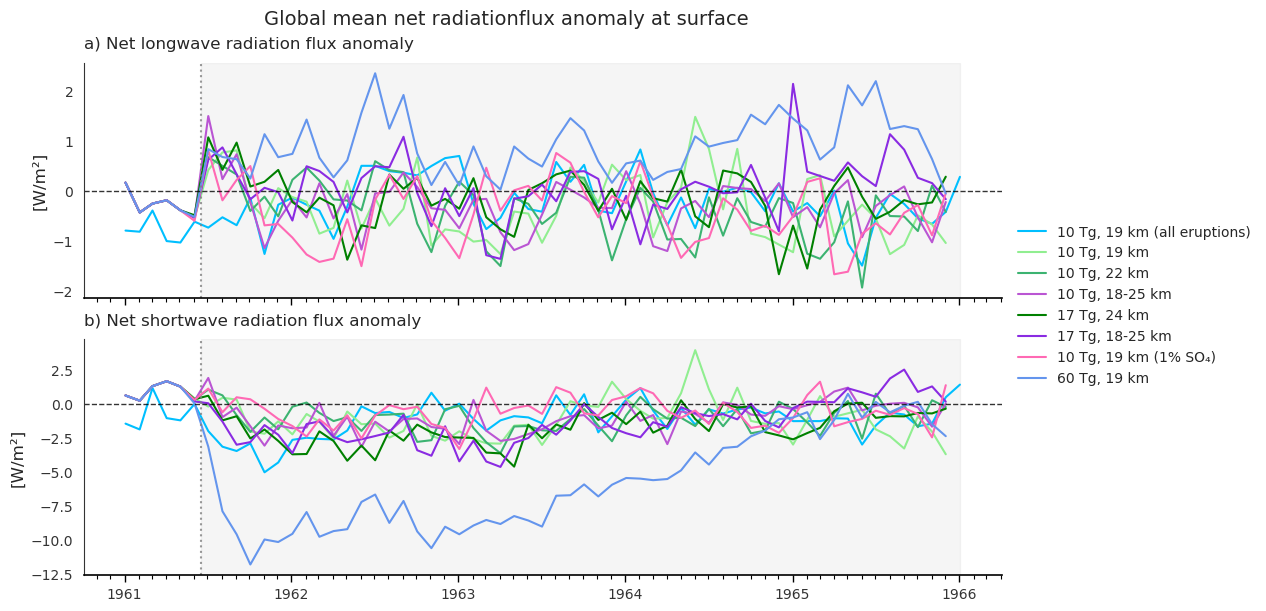

In [ ]:
sns.set_style("whitegrid", {'axes.grid': False})
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'

eruption_date=cftime.DatetimeNoLeap(1991, 6, 15)

fig, (ax_lw, ax_sw) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, constrained_layout=True)


ax_lw.plot(netlwsurf_anom.time, netlwsurf_anom, color="deepskyblue", lw=1.5,label="10 Tg, 19 km (all eruptions)")
ax_lw.plot(netlwsurf_19_c_anom.time, netlwsurf_19_c_anom, color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax_lw.plot(netlwsurf_22_anom.time, netlwsurf_22_anom,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax_lw.plot(netlwsurf_1825_anom.time, netlwsurf_1825_anom,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax_lw.plot(netlwsurf_24_anom.time, netlwsurf_24_anom,color="green", lw=1.5,label="17 Tg, 24 km")
ax_lw.plot(netlwsurf_1825_17tg_anom.time, netlwsurf_1825_17tg_anom,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax_lw.plot(netlwsurf_1pr_anom.time, netlwsurf_1pr_anom,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax_lw.plot(netlwsurf_60tg_anom.time, netlwsurf_60tg_anom,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km ")

ax_sw.plot(netswsurf_anom.time, netswsurf_anom,color="deepskyblue", lw=1.5)
ax_sw.plot(netswsurf_19_c_anom.time, netswsurf_19_c_anom,color="lightgreen", lw=1.5)
ax_sw.plot(netswsurf_22_anom.time, netswsurf_22_anom,color="mediumseagreen", lw=1.5)
ax_sw.plot(netswsurf_1825_anom.time, netswsurf_1825_anom,color="mediumorchid", lw=1.5)
ax_sw.plot(netswsurf_24_anom.time, netswsurf_24_anom,color="green", lw=1.5)
ax_sw.plot(netswsurf_1825_17tg_anom.time, netswsurf_1825_17tg_anom,color="blueviolet", lw=1.5)
ax_sw.plot(netswsurf_1pr_anom.time, netswsurf_1pr_anom,color="hotpink", lw=1.5)
ax_sw.plot(netswsurf_60tg_anom.time, netswsurf_60tg_anom,color="cornflowerblue", lw=1.5)

axes = [ax_lw, ax_sw]
titles = ["a) Net longwave radiation flux anomaly", "b) Net shortwave radiation flux anomaly"]

for i, ax in enumerate(axes):
    ax.axhline(0, color="black", lw=1.0, ls='--', alpha=0.8)
    ax.axvline(eruption_date, color='gray', ls = ":", alpha=0.8)
    ax.axvspan(eruption_date, cftime.DatetimeNoLeap(1996, 1, 1), color='gray', alpha=0.08, zorder=0)
    ax.tick_params(direction='out', length=4)
    ax.set_ylabel("[W/m²]", fontsize=12)
    ax.set_title(titles[i], loc='left', fontsize=12, pad=10)
    
    sns.despine(ax=ax)

for ax in [ax_lw, ax_sw]:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_minor_locator(mdates.MonthLocator()) 
    
    ax.tick_params(axis='x', which='major', bottom=True, length=5, width=1, color='black')
    ax.tick_params(axis='x', which='minor', bottom=True, length=3, width=0.8, color='black')
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.2)

ax_sw.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle("Global mean net radiationflux anomaly at surface", fontsize=14)

fig.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=10
)

plt.show()


In [37]:
temp_ctrl = ds_19["TREFHT"].weighted(weighted_lat).mean(dim=["lat", "lon"]) - 273.15
baseline = temp_ctrl.sel(time=slice("1975-01", "1985-12"))
base = baseline.groupby("time.month").mean("time")

In [38]:
temp_19_c = ds_19_c["TREFHT"].weighted(weighted_lat_19_c).mean(dim = ["lat", "lon"]) -273.15
t_anom_19_c = temp_19_c.groupby("time.month") - base
temp_60tg = ds_60tg["TREFHT"].weighted(weighted_lat_60tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_60tg = temp_60tg.groupby("time.month") - base
temp_22 = ds_22["TREFHT"].weighted(weighted_lat_22).mean(dim = ["lat", "lon"]) -273.15
t_anom_22 = temp_22.groupby("time.month") - base
temp_24 = ds_24["TREFHT"].weighted(weighted_lat_24).mean(dim = ["lat", "lon"]) -273.15
t_anom_24 = temp_24.groupby("time.month") - base
temp_1825 = ds_1825["TREFHT"].weighted(weighted_lat_1825).mean(dim = ["lat", "lon"]) -273.15
t_anom_1825 = temp_1825.groupby("time.month") - base
temp_1825_17tg = ds_1825_17tg["TREFHT"].weighted(weighted_lat_1825_17tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_1825_17tg = temp_1825_17tg.groupby("time.month") - base
temp_1tg = ds_1tg["TREFHT"].weighted(weighted_lat_1tg).mean(dim = ["lat", "lon"]) -273.15
t_anom_1tg = temp_1tg.groupby("time.month") - base
temp_1pr = ds_1pr["TREFHT"].weighted(weighted_lat_1pr).mean(dim = ["lat", "lon"]) -273.15
t_anom_1pr = temp_1pr.groupby("time.month") - base

<>:37: SyntaxWarning: invalid escape sequence '\c'
<>:37: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_3352028/3118508042.py:37: SyntaxWarning: invalid escape sequence '\c'
  ax_t.set_ylabel("[$^\circ$C]")


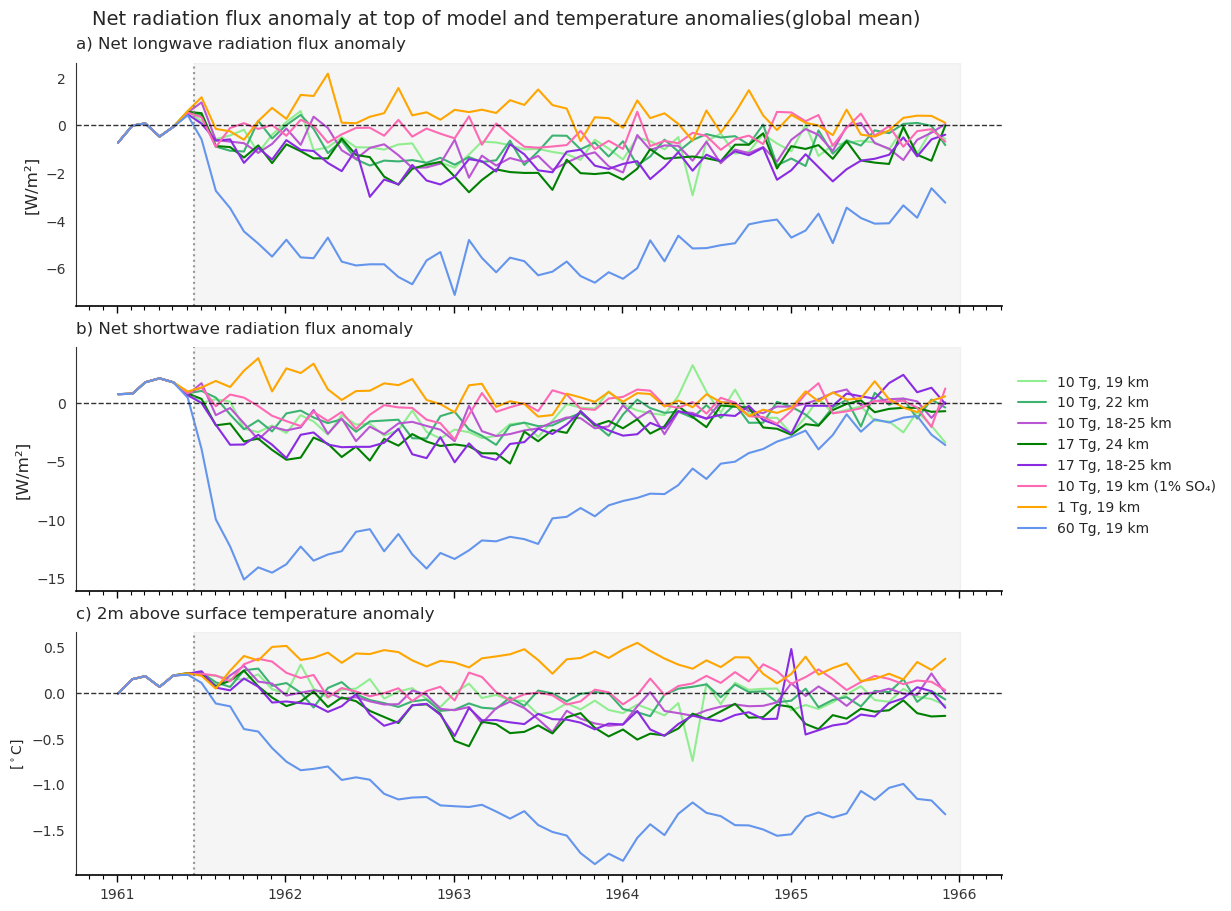

In [41]:
sns.set_style("whitegrid", {'axes.grid': False})
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['xtick.color'] = '#333333'
plt.rcParams['ytick.color'] = '#333333'

eruption_date=cftime.DatetimeNoLeap(1991, 6, 15)
fig, (ax_lw, ax_sw, ax_t) = plt.subplots(3, 1, figsize=(10, 9), sharex=True, constrained_layout=True)

ax_lw.plot(netlwtom_19_c_anom.time, netlwtom_19_c_anom,color="lightgreen", lw=1.5,label="10 Tg, 19 km")
ax_lw.plot(netlwtom_22_anom.time, netlwtom_22_anom,color="mediumseagreen", lw=1.5,label="10 Tg, 22 km")
ax_lw.plot(netlwtom_1825_anom.time, netlwtom_1825_anom,color="mediumorchid", lw=1.5,label="10 Tg, 18-25 km")
ax_lw.plot(netlwtom_24_anom.time, netlwtom_24_anom,color="green", lw=1.5,label="17 Tg, 24 km")
ax_lw.plot(netlwtom_1825_17tg_anom.time, netlwtom_1825_17tg_anom,color="blueviolet", lw=1.5,label="17 Tg, 18-25 km")
ax_lw.plot(netlwtom_1pr_anom.time, netlwtom_1pr_anom,color="hotpink", lw=1.5,label="10 Tg, 19 km (1% SO₄)")
ax_lw.plot(netlwtom_1tg_anom.time, netlwtom_1tg_anom,color="orange", lw=1.5, label="1 Tg, 19 km")
ax_lw.plot(netlwtom_60tg_anom.time, netlwtom_60tg_anom,color="cornflowerblue", lw=1.5,label="60 Tg, 19 km")
ax_lw.set_ylabel("[W/m²]", fontsize=12)

ax_sw.plot(netswtom_19_c_anom.time, netswtom_19_c_anom,color="lightgreen", lw=1.5)
ax_sw.plot(netswtom_22_anom.time, netswtom_22_anom,color="mediumseagreen", lw=1.5)
ax_sw.plot(netswtom_1825_anom.time, netswtom_1825_anom,color="mediumorchid", lw=1.5)
ax_sw.plot(netswtom_24_anom.time, netswtom_24_anom,color="green", lw=1.5)
ax_sw.plot(netswtom_1825_17tg_anom.time, netswtom_1825_17tg_anom,color="blueviolet", lw=1.5)
ax_sw.plot(netswtom_1pr_anom.time, netswtom_1pr_anom,color="hotpink", lw=1.5)
ax_sw.plot(netswtom_1tg_anom.time, netswtom_1tg_anom,color="orange", lw = 1.5)
ax_sw.plot(netswtom_60tg_anom.time, netswtom_60tg_anom,color="cornflowerblue", lw=1.5)
ax_sw.set_ylabel("[W/m²]", fontsize=12)

ax_t.plot(t_anom_19_c.time, t_anom_19_c,color="lightgreen", lw=1.5)
ax_t.plot(t_anom_22.time, t_anom_22,color="mediumseagreen", lw=1.5)
ax_t.plot(t_anom_1825.time, t_anom_1825,color="mediumorchid", lw=1.5)
ax_t.plot(t_anom_24.time, t_anom_24,color="green", lw=1.5)
ax_t.plot(t_anom_1825_17tg.time, t_anom_1825_17tg,color="blueviolet", lw=1.5)
ax_t.plot(t_anom_1pr.time, t_anom_1pr,color="hotpink", lw=1.5)
ax_t.plot(t_anom_1tg.time, t_anom_1tg, color="orange", lw=1.5)
ax_t.plot(t_anom_60tg.time, t_anom_60tg,color="cornflowerblue", lw=1.5)
ax_t.set_ylabel("[$^\circ$C]")

axes = [ax_lw, ax_sw, ax_t]
titles = ["a) Net longwave radiation flux anomaly", "b) Net shortwave radiation flux anomaly", "c) 2m above surface temperature anomaly"]

for i, ax in enumerate(axes):
    ax.axhline(0, color="black", lw=1.0, ls='--', alpha=0.8)
    ax.axvline(eruption_date, color='gray', ls = ":", alpha=0.8)
    ax.axvspan(eruption_date, cftime.DatetimeNoLeap(1996, 1, 1), color='gray', alpha=0.08, zorder=0)
    ax.tick_params(direction='out', length=4)
    ax.set_title(titles[i], loc='left', fontsize=12, pad=10)
    
    sns.despine(ax=ax)

for ax in [ax_lw, ax_sw, ax_t]:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_minor_locator(mdates.MonthLocator()) 
    
    ax.tick_params(axis='x', which='major', bottom=True, length=5, width=1, color='black')
    ax.tick_params(axis='x', which='minor', bottom=True, length=3, width=0.8, color='black')
    ax.spines['bottom'].set_visible(True)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.2)

ax_sw.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.legend(
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=10
)

plt.suptitle("Net radiation flux anomaly at top of model and temperature anomalies(global mean)", fontsize=14)
plt.show()
